# Alpha factory prototype
the financial type of alpha. Could have called it edge factory



In [4]:
%load_ext autoreload
%autoreload 2
from collections import deque
from lib.kdb_interface import kdb_link as kdb

import pandas as pd
import random 
import numpy as np
import math 
import copy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
ops = ["+", "-", "*", "/"]
DATA_WINDOW_LENGTH = 200



### indicators

In [6]:
# simple moving average
def SMA(data_window, lag_window=20, col="Close"):
    if len(data_window) < lag_window:
        return None
    window = [bar[col] for bar in data_window]
    return sum(window[-lag_window:]) / lag_window



# ADX is a momentum oscillator which can offer insights into whether an asset is trending and if so how significantly. 
# It quantifies price action, allowing traders to see whether a particular move falls within a trending or non-trending market
# aiding entry or exit decisions. 
# from: https://tabtrader.com/academy/articles/average-directional-index-adx-explained

# I love side effects
ADX_prior_smoothed_plus_dm = 0.0
ADX_prior_smoothed_minus_dm = 0.0
ADX_prior_ATR = 0.0
ADX_prior_ADX = 0.0
ADX_dx_history = [] 

# yea holy fuck i tried, but i just had gemini make it
"Avg Directional Index, Trend strength"
# Returns a value between 0 and 100, with higher values indicating a stronger trend. Either skyrocketing or plummeting. 
# 20 to 25: A trend is starting to break out or form.
# 25 to 50: A strong, established trend is underway.
# Over 50: An extremely strong, historic trend (often unsustainable over the long term).
def ADX(data_window, window=14):
    global ADX_prior_smoothed_plus_dm, ADX_prior_smoothed_minus_dm
    global ADX_prior_ATR, ADX_prior_ADX, ADX_dx_history

    if len(data_window) < 2:
        return None
    
    prev_bar = data_window[-2]
    last_bar = data_window[-1]

    # 1. Calculate Raw Directional Movement
    up_move = last_bar["High"] - prev_bar["High"]
    down_move = prev_bar["Low"] - last_bar["Low"]

    current_plus_dm = 0
    current_minus_dm = 0

    if up_move > down_move and up_move > 0:
        current_plus_dm = up_move
    elif down_move > up_move and down_move > 0:
        current_minus_dm = down_move

    # 2. Wilder's Smoothing for both DM tracks independently
    smoothed_plus_dm_today = ADX_prior_smoothed_plus_dm - (ADX_prior_smoothed_plus_dm / window) + current_plus_dm
    smoothed_minus_dm_today = ADX_prior_smoothed_minus_dm - (ADX_prior_smoothed_minus_dm / window) + current_minus_dm

    # 3. Calculate True Range and Smoothed ATR
    # Note: Using your key case lowercase 'close' from your original snippet
    true_range = max(
        last_bar["High"] - last_bar["Low"], 
        abs(last_bar["High"] - prev_bar["Close"]), 
        abs(last_bar["Low"] - prev_bar["Close"])
    )
    
    ATR_today = ADX_prior_ATR - (ADX_prior_ATR / window) + true_range

    # Guard against division by zero if ATR is completely flat
    if ATR_today == 0:
        return 0

    # 4. Calculate Directional Indicators (Fixed algebraic syntax matching your image)
    pos_DI = (smoothed_plus_dm_today / ATR_today) * 100
    neg_DI = (smoothed_minus_dm_today / ATR_today) * 100

    # 5. Calculate DX (Added absolute value to match image)
    dx_denom = pos_DI + neg_DI
    DX = (abs(pos_DI - neg_DI) / dx_denom * 100) if dx_denom != 0 else 0

    # 6. Smooth DX to get final ADX
    ADX_dx_history.append(DX)
    
    if len(ADX_dx_history) < window:
        # We don't have enough days yet to calculate an ADX baseline
        current_adx = 0 
    elif len(ADX_dx_history) == window:
        # First ADX point is a Simple Moving Average of the first 14 DX values
        current_adx = sum(ADX_dx_history) / window
    else:
        # Standard day-to-day rolling ADX formula
        current_adx = (ADX_prior_ADX * (window - 1) + DX) / window

    # 7. Update your global state variables for tomorrow's run
    ADX_prior_smoothed_plus_dm = smoothed_plus_dm_today
    ADX_prior_smoothed_minus_dm = smoothed_minus_dm_today
    ADX_prior_ATR = ATR_today
    ADX_prior_ADX = current_adx

    return current_adx







# RSI measures the speed and magnitude of a security's recent price changes
"relative strength index, The velocity of the price change and the magnitude of the price change"
# returns 0 to 100, with high values indicating overbought conditions and low values indicating oversold conditions
# 0 to 30: Oversold conditions, potential buying opportunity.
# 30 to 70: Neutral zone, no clear overbought or oversold conditions.
# 70 to 100: Overbought conditions, potential selling opportunity.
def RSI(data_window, window=14, col="Close"):
    if len(data_window) < 2:
        return None
    
    gains = []
    losses = []
    
    for i in range(1, min(len(data_window), window + 1)):
        change = data_window[-i][col] - data_window[-i - 1][col]
        if change > 0:
            gains.append(change)
            losses.append(0)
        else:
            gains.append(0)
            losses.append(-change)

    avg_gain = sum(gains) / window
    avg_loss = sum(losses) / window

    if avg_loss == 0:
        return 100  # Prevent division by zero; implies very strong upward momentum

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi


# measures the closing price of a security relative to its high-low range over a specific period
"stochastic oscillator, The position of the current close relative to the recent trading range"
# returns 0 to 100, with high values indicating overbought conditions and low values indicating oversold conditions
# Under 20: The asset is oversold, closing near the bottom of its recent range.
# 20 to 80: The asset is trading within its normal historical range.
# Over 80: The asset is overbought, closing near the top of its recent range.
def stochastic_oscillator(data_window, window=14, col="Close"):
    if len(data_window) < window:
        return None
    
    recent_window = list(data_window)[-window:]
    highest_high = max(bar["High"] for bar in recent_window)
    lowest_low = min(bar["Low"] for bar in recent_window)
    
    if highest_high == lowest_low:
        return 50  # Prevent division by zero; implies no price movement

    last_close = data_window[-1][col]
    k_percent = ((last_close - lowest_low) / (highest_high - lowest_low)) * 100
    
    return k_percent


# the point in which i gave up lol


# -------------------------------------------------------
# ATR - Average True Range
# -------------------------------------------------------
ATR_prior = 0.0

"Average True Range, Absolute volatility — how much is price actually moving?"
# Returns the average size of price moves over the window period, in price units.
# Small ATR: Low volatility, price is consolidating.
# Large ATR: High volatility, price is making big moves.
def ATR(data_window, window=14):
    global ATR_prior

    if len(data_window) < 2:
        return None

    prev_bar = data_window[-2]
    last_bar = data_window[-1]

    true_range = max(
        last_bar["High"] - last_bar["Low"],
        abs(last_bar["High"] - prev_bar["Close"]),
        abs(last_bar["Low"] - prev_bar["Close"])
    )

    # Wilder's smoothing (same method as ADX)
    if ATR_prior == 0.0:
        ATR_prior = true_range
        return ATR_prior

    ATR_today = ATR_prior - (ATR_prior / window) + true_range
    ATR_prior = ATR_today
    return ATR_today


# -------------------------------------------------------
# Bollinger Band Width
# -------------------------------------------------------
"Bollinger Band Width, Relative volatility — is the market squeezing or expanding?"
# Returns (upper - lower) / middle, i.e. band width as a fraction of price.
# Falling width (squeeze): Volatility is contracting, often precedes a big move.
# Rising width: Volatility is expanding, trend is accelerating.
def bollinger_band_width(data_window, window=20, num_std=2, col="Close"):
    if len(data_window) < window:
        return None

    closes = [bar[col] for bar in list(data_window)[-window:]]
    mean = sum(closes) / window
    variance = sum((c - mean) ** 2 for c in closes) / window
    std = variance ** 0.5

    upper = mean + num_std * std
    lower = mean - num_std * std

    if mean == 0:
        return None

    return (upper - lower) / mean


# -------------------------------------------------------
# OBV - On-Balance Volume
# -------------------------------------------------------
OBV_prior_value = 0.0
OBV_prior_close = None

"On-Balance Volume, Cumulative volume flow — are buyers or sellers in control?"
# Returns a running cumulative total (no fixed range).
# Rising OBV with rising price: Strong uptrend confirmed by volume.
# Falling OBV with rising price: Divergence — move may not be sustainable.
def OBV(data_window):
    global OBV_prior_value, OBV_prior_close

    if len(data_window) < 1:
        return None

    last_bar = data_window[-1]
    current_close = last_bar["Close"]
    current_volume = last_bar["Volume"]

    if OBV_prior_close is None:
        OBV_prior_close = current_close
        return OBV_prior_value

    if current_close > OBV_prior_close:
        OBV_prior_value += current_volume
    elif current_close < OBV_prior_close:
        OBV_prior_value -= current_volume
    # equal close: OBV unchanged

    OBV_prior_close = current_close
    return OBV_prior_value


# -------------------------------------------------------
# CMF - Chaikin Money Flow
# -------------------------------------------------------
"Chaikin Money Flow, Accumulation vs. distribution — who is winning over the window?"
# Returns a value between -1 and +1.
# Above 0: Accumulation (buying pressure dominant).
# Below 0: Distribution (selling pressure dominant).
# Above +0.25 or below -0.25: Strong signal.
def CMF(data_window, window=20):
    if len(data_window) < window:
        return None

    recent = list(data_window)[-window:]

    total_mfv = 0.0
    total_volume = 0.0

    for bar in recent:
        high = bar["High"]
        low = bar["Low"]
        close = bar["Close"]
        volume = bar["Volume"]

        price_range = high - low
        if price_range == 0:
            mfm = 0.0
        else:
            mfm = ((close - low) - (high - close)) / price_range

        total_mfv += mfm * volume
        total_volume += volume

    if total_volume == 0:
        return 0.0

    return total_mfv / total_volume


# -------------------------------------------------------
# Z-Score of Price
# -------------------------------------------------------
"Z-Score of Price, Mean reversion — how stretched is price from its average?"
# Returns standard deviations from the mean. No fixed range but typically -3 to +3.
# Above +2: Price is historically high relative to recent average, may revert down.
# Below -2: Price is historically low relative to recent average, may revert up.
# Near 0: Price is close to its recent mean.
def z_score(data_window, window=20, col="Close"):
    if len(data_window) < window:
        return None

    closes = [bar[col] for bar in list(data_window)[-window:]]
    mean = sum(closes) / window
    variance = sum((c - mean) ** 2 for c in closes) / window
    std = variance ** 0.5

    if std == 0:
        return 0.0

    return (closes[-1] - mean) / std


# -------------------------------------------------------
# Donchian Channel Position
# -------------------------------------------------------
"Donchian Channel Position, Range position — where is price within its recent high/low range?"
# Returns 0 to 1, where 0 = at the lowest low and 1 = at the highest high.
# Above 0.8: Price near top of range, potential breakout or overbought.
# Below 0.2: Price near bottom of range, potential breakdown or oversold.
# Near 0.5: Price in the middle of the range.
def donchian_channel_position(data_window, window=20, col="Close"):
    if len(data_window) < window:
        return None

    recent = list(data_window)[-window:]
    highest_high = max(bar["High"] for bar in recent)
    lowest_low = min(bar["Low"] for bar in recent)

    if highest_high == lowest_low:
        return 0.5  # No range movement

    current_close = data_window[-1][col]
    return (current_close - lowest_low) / (highest_high - lowest_low)


# tags are there so when GP is creating new indicators it wont add exact matches
functions = {
    1 : {"function" : SMA, "name" : "SMA", "categories": ["trend"], "type": "lagging"}, 
    2 : {"function" : ADX, "name" : "ADX", "categories": ["trend"], "type": "lagging"}, 
    3 : {"function" : RSI, "name" : "RSI", "categories": ["momentum"], "type": "leading"}, 
    4 : {"function" : stochastic_oscillator, "name" : "stochastic_oscillator", "categories": ["momentum"], "type": "leading"}, 
    5 : {"function" : ATR, "name" : "ATR", "categories": ["volatility"], "type": "coincident"}, 
    6 : {"function" : bollinger_band_width, "name" : "bollinger_band_width", "categories": ["volatility"], "type": "coincident"}, 
    7 : {"function" : OBV, "name" : "OBV", "categories": ["volume"], "type": "lagging"}, 
    8 : {"function" : CMF, "name" : "CMF", "categories": ["volume"], "type": "leading"}, 
    9 : {"function" : z_score, "name" : "z_score", "categories": ["statistical"], "type": "leading"}, 
    10 : {"function" : donchian_channel_position, "name" : "donchian_channel_position", "categories": ["trend"], "type": "coincident"}
}

function_categories = {
    SMA: {"categories": ["trend"], "type": "lagging"},
    ADX: {"categories": ["trend"], "type": "lagging"},  
    RSI: {"categories": ["momentum"], "type": "leading"},
    stochastic_oscillator: {"categories": ["momentum"], "type": "leading"},
    ATR: {"categories": ["volatility"], "type": "coincident"},
    bollinger_band_width: {"categories": ["volatility"], "type": "coincident"},
    OBV: {"categories": ["volume"], "type": "lagging"},
    CMF: {"categories": ["volume"], "type": "leading"},
    z_score: {"categories": ["statistical"], "type": "leading"},
    donchian_channel_position: {"categories": ["trend"], "type": "coincident"}  
}


In [7]:
params = {
         "script_path": "/home/mica/finProject/finStuff/databases/db_handler_alpha_fac.q", 
         "database_path": "/home/mica/finProject/finStuff/databases/db", 
         "start_date": "2021.01.01", 
         "end_date": "2021.12.31", 
         "ticker": "JPM",
         "timeframe": "1d"
         }



data_window = deque(maxlen=DATA_WINDOW_LENGTH)

jpm = kdb(params=params, chunk_size=100)
i = 0

dates = pd.date_range(start="2021-01-01", periods=1, freq="D")
data = pd.DataFrame(data={'price': 0, **{functions[key]["name"]: 0 for key in functions}}, index=dates)



#main loop for this
while True:
    i += 1
    df = jpm.read_chunk()

    if df is None:
        print(f"done after {i} chunks")
        break

    for i in range(len(df)):
        data_window.append(df.iloc[i])
        
        data = pd.concat([data, pd.DataFrame({
            "price": df.iloc[i]["Close"],
            **{functions[key]["name"]: functions[key]["function"](data_window) for key in functions}
        }, index=[df.index[i]])], ignore_index=False)

        for key in functions:
            func = functions[key]["function"]
            result = func(data_window)
            print(f"{func.__name__}: {result}")
        
data.to_csv("jpm_indicators_preprocessed_out_of_sample_2021.csv")
    


reading chunk
Querying kdb for data from 2021-01-01 00:00:00 to 2021-04-11 00:00:00
SMA: None
ADX: None
RSI: None
stochastic_oscillator: None
ATR: None
bollinger_band_width: None
OBV: 0.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 100
stochastic_oscillator: None
ATR: 4.512841663066708
bollinger_band_width: None
OBV: 13731200.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 100
stochastic_oscillator: None
ATR: 16.591348960074903
bollinger_band_width: None
OBV: 38640300.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 100
stochastic_oscillator: None
ATR: 26.149789905082216
bollinger_band_width: None
OBV: 60580700.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 100
stochastic_oscillator: None
ATR: 26.525255049530564
bollinger_band_width: None
OBV: 72615800.0
CMF: None
z_score: None
donchian_channel_position: None
SMA: None
ADX: 0
RSI: 100
stochastic_oscillator: 

In [290]:
class node:
    def __init__(self, data="", left=None, right=None):
        self.fitness = 0
        self.moves = 0  # Fixed: changed from local variable to instance attribute
        self.data = data
        self.left = left
        self.right = right

    def is_leaf(self):
        return self.left is None and self.right is None

    def __repr__(self):
        if self.is_leaf():
            return str(self.data)
        return f"({self.left} {self.data} {self.right})"

    def get_indicators(self):
        indicators = set()
        if self.is_leaf():
            # Matches against string names in your configuration
            if self.data in [functions[key]["name"] for key in functions]:
                indicators.add(self.data)
        else:
            indicators.update(self.left.get_indicators())
            indicators.update(self.right.get_indicators())
        return indicators

    def calculate(self, df_row):
        if self.is_leaf():
            return float(df_row[self.data])
 
        left_val = self.left.calculate(df_row)
        right_val = self.right.calculate(df_row)
 
        if self.data == "+":
            return left_val + right_val
        elif self.data == "-":
            return left_val - right_val
        elif self.data == "*":
            return left_val * right_val
        elif self.data == "/":
            if right_val == 0:
                return 0.0
            return left_val / right_val
 
        raise ValueError(f"Unknown operator: {self.data}")

    def set_fitness(self, fitness):
        self.fitness = fitness

    # --- NEW EVOLUTION FUNCTIONS ---

    def get_all_nodes(self):
        """
        Recursively collects references to all nodes in the tree.
        Used by crossover and mutation to pick random edit points.
        """
        nodes = [self]
        if not self.is_leaf():
            if self.left:
                nodes.extend(self.left.get_all_nodes())
            if self.right:
                nodes.extend(self.right.get_all_nodes())
        return nodes

    def copy(self):
        """
        Creates a deep copy of the tree structure.
        Prevents mutations to children from altering the parent histories.
        """
        new_node = node(data=self.data)
        new_node.fitness = self.fitness
        new_node.moves = self.moves
        if self.left:
            new_node.left = self.left.copy()
        if self.right:
            new_node.right = self.right.copy()
        return new_node

    def get_diversity_multiplier(self):
        """
        Uses your category strategy rule to penalize models that pack 
        redundant styles of technical indicators together.
        """
        used_indicators = self.get_indicators()
        
        if not used_indicators:
            return 0.0  # Formula is somehow empty or has zero TIs
            
        unique_categories = set()
        
        # Cross-reference the string name back to your category lists
        for ind_name in used_indicators:
            for key, meta in functions.items():
                if meta["name"] == ind_name:
                    unique_categories.update(meta["categories"])
                    break
                    
        num_categories = len(unique_categories)
        num_total_indicators = len(used_indicators)
        
        # Calculate C / Total ratio
        return float(num_categories / num_total_indicators)

In [291]:
def build_tree(current_depth, max_depth, method="grow"):
    if current_depth == max_depth:
        return node(data=random.choice(list(functions.values()))["name"])
    
    if method == "grow" and current_depth > 0:
        # 50% chance to terminate early and pick a leaf node
        if random.random() < 0.5:
            return node(data=random.choice(list(functions.values()))["name"])
        
    root = node(data=random.choice(ops))
    root.left = build_tree(current_depth + 1, max_depth, method)
    root.right = build_tree(current_depth + 1, max_depth, method)
    
    return root



In [292]:
#creating the initial population
FITNESS_CUTOFF = 0.3
INITIAL_POPULATION = 500
GENERATIONS = 25
MAX_DEPTH = 5

df = pd.read_csv('jpm_indicators_preprocessed.csv')
programs = []


for i in range(INITIAL_POPULATION):
    # Alternate methods between Full and Grow to maintain diversity
    method = "full" if i % 2 == 0 else "grow"
    
    # If you want to vary depths (Ramped), you could also fluctuate the max_depth parameter here
    tree_root = build_tree(current_depth=0, max_depth=MAX_DEPTH, method=method)
    programs.append(tree_root)

# Let's inspect a few generated expressions to ensure they look right
print("Sample expressions from initial population:")
for i in range(5):
    print(f"Program {i}: {programs[i]}")


Sample expressions from initial population:
Program 0: (((((ADX / donchian_channel_position) + (stochastic_oscillator * ADX)) / ((RSI + ATR) + (stochastic_oscillator * OBV))) + (((donchian_channel_position + RSI) * (bollinger_band_width - SMA)) + ((OBV * OBV) / (CMF - bollinger_band_width)))) + ((((ATR / RSI) - (ATR + z_score)) + ((RSI - z_score) - (donchian_channel_position - donchian_channel_position))) - (((stochastic_oscillator / ATR) * (z_score * RSI)) * ((CMF * CMF) / (OBV + bollinger_band_width)))))
Program 1: ((stochastic_oscillator - bollinger_band_width) / (RSI / RSI))
Program 2: (((((RSI * bollinger_band_width) - (donchian_channel_position - RSI)) / ((SMA / OBV) - (donchian_channel_position - stochastic_oscillator))) - (((OBV + ADX) - (stochastic_oscillator + SMA)) - ((OBV + ADX) * (OBV / bollinger_band_width)))) + ((((bollinger_band_width / donchian_channel_position) + (OBV * SMA)) - ((stochastic_oscillator + donchian_channel_position) - (donchian_channel_position * RSI))) 

In [293]:
for i in range(10):
    print(programs[i].calculate(df.iloc[100]))

-3.412918857233892e+18
76.53966218137425
1.498345281417813e+17
0.058195853637666564
-18679015389748.926
98.13223449566289
5994160566879.339
142424195330.34366
2878.5980174019974
-8282.974495178927


In [294]:
def simple_framework(program, data):
    result = program.calculate(data)

    if result > 0:
        return 1  # Buy signal
    elif result < 0:
        return -1  # Sell signal
    else:
        return 0  # Hold signal

def sigmoid_framework(program, data):
    try:
        result = program.calculate(data)
    except Exception as e:
        print(f"Error calculating program: {e}")
        return 0  # Default to hold on error

    # for when we have way to big or small values from the program
    if result > 10:
        sigmoid_result = 1
    elif result < -10:
        sigmoid_result = 0
    else:
        sigmoid_result = 1 / (1 + math.exp(-result))
    
    return sigmoid_result
    #if sigmoid_result > 0.6:
    #    return 1  # Buy signal
    #elif sigmoid_result < 0.4:
    #    return -1  # Sell signal
    #else:
    #    return 0  # Hold signal


def simple_signal_evaluator(signal):
    if signal == 1:
        return 1
    else:
        return 0
    
def tournament_selection(population, tournament_size=3):
    # Pick random candidates from the population
    candidates = random.sample(population, tournament_size)
    # The winner is the one with the highest fitness (e.g., -0.0005 beats -0.004)
    winner = max(candidates, key=lambda program: program.fitness)
    return winner


def crossover(parent_a, parent_b):
    # Deep copy the parents so we don't mutate the originals
    child_a = copy.deepcopy(parent_a)
    child_b = copy.deepcopy(parent_b)
    
    # 1. Get a list of all node references in both children
    nodes_a = child_a.get_all_nodes() # Internal method returning a list of pointers to nodes
    nodes_b = child_b.get_all_nodes()
    
    # 2. Pick a random crossover point in each tree
    target_node_a = random.choice(nodes_a)
    target_node_b = random.choice(nodes_b)
    
    # 3. Swap the sub-trees in place
    # Swap their functions, left children, and right children
    target_node_a.data, target_node_b.data = target_node_b.data, target_node_a.data
    target_node_a.left, target_node_b.left = target_node_b.left, target_node_a.left
    target_node_a.right, target_node_b.right = target_node_b.right, target_node_a.right
    
    return child_a, child_b

def generate_random_tree(max_depth, method="grow", current_depth=0):
    """
    Create a random subtree compatible with your `node` class.

    max_depth: remaining depth budget for this subtree
    method:
      - "full": force operator nodes until depth limit
      - "grow": allow early leaf termination
    """
    # Always stop at depth limit (or if caller gives negative depth)
    if max_depth <= 0:
        return node(data=random.choice(list(functions.values()))["name"])

    # In grow mode, optionally stop early with a leaf
    if method == "grow" and current_depth > 0 and random.random() < 0.5:
        return node(data=random.choice(list(functions.values()))["name"])

    # Otherwise create an operator node and recurse
    root = node(data=random.choice(ops))
    root.left = generate_random_tree(max_depth - 1, method=method, current_depth=current_depth + 1)
    root.right = generate_random_tree(max_depth - 1, method=method, current_depth=current_depth + 1)
    return root


def mutate(program, functions_dict, operators_list, max_depth=2):
    mutated_program = program.copy()
    nodes = mutated_program.get_all_nodes()
    target_node = random.choice(nodes)
    
    # Flip a coin: 50% change just the node value, 50% replace with a new random sub-tree
    if random.random() < 0.5:
        if target_node.is_leaf():
            # Change to a different random technical indicator ID
            target_node.data = random.choice(list(functions_dict.keys()))
        else:
            # Change to a different math operator (+, -, *, /)
            target_node.data = random.choice(operators_list)
    else:
        # Generate a brand new random sub-tree and attach it here
        target_node.left = generate_random_tree(max_depth - 1)
        target_node.right = generate_random_tree(max_depth - 1)
        target_node.data = random.choice(operators_list)
        
    return mutated_program

In [295]:
print(df.count())

Unnamed: 0                   1663
price                        1663
SMA                          1644
ADX                          1662
RSI                          1662
stochastic_oscillator        1650
ATR                          1662
bollinger_band_width         1644
OBV                          1663
CMF                          1644
z_score                      1644
donchian_channel_position    1644
dtype: int64


In [296]:

# the evolution loop
for generation in range(GENERATIONS):
    for program in programs:
        portfolio_value = 1000
        portfolio_owned = 0 # percentage of the portfolio owned in the stock, 0 to 1
        strategy_returns = []
        
        position_changes = 0
        moves = []
        previous_price = 0
        previous_port_value = 0 # for calculating log returns
        previous_row = None
        for index, row in df.iterrows():
        
            delta = row["price"] - previous_price #this has to be the forward move
            previous_price = row["price"]
            step_pnl = delta * portfolio_owned
            portfolio_value += step_pnl
            
            if portfolio_value <= 0: # bankrupcy
                log_returns = -1
                break
            else:
                log_returns = math.log(portfolio_value / previous_port_value) if previous_port_value > 0 else 0
            
            strategy_returns.append(log_returns)
            previous_port_value = portfolio_value

           

            signal = sigmoid_framework(program, previous_row) if previous_row is not None else 0 # this has to be previous row to prevent lookahead bias
            portfolio_owned = signal #simple_signal_evaluator(signal)

            if len(moves) > 0 and signal != moves[-1]: position_changes += 1
            moves.append(signal)

            previous_row = row



        # Convert your list to a numpy array so you can filter it
        returns_arr = np.array(strategy_returns)
        program.moves = position_changes
        wins = returns_arr[returns_arr > 0]
        losses = returns_arr[returns_arr < 0]

        # Guardrail: Prevent division by zero if it never traded
        if len(returns_arr) == 0 or (len(wins) == 0 and len(losses) == 0):
            program.set_fitness(0)
            continue

        p = len(wins) / len(returns_arr)
        q = 1 - p

        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = np.abs(np.mean(losses)) if len(losses) > 0 else 0
        
        #final checking for cases where the strategy just buys and holds or stays in cash
        high_end_count = sum(1 for m in moves if m > 0.9)
        low_end_count = sum(1 for m in moves if m < 0.1)
        
        
        # Calculate the raw fitness first
        raw_fitness = p * avg_win - q * avg_loss
        
        # Calculate what % of the time they spent maxed out
        cash_ratio = low_end_count / df.shape[0]
        hold_ratio = high_end_count / df.shape[0]
        
        # Apply a dynamic penalty multiplier instead of a hard overwrite
        penalty = 1.0
        
        #if cash_ratio > 0.95:
        #    penalty *= 0.01  # Slashes fitness by 99%, but preserves the relative ranking
        #if hold_ratio > 0.95:
        #    penalty *= 0.01  # Slashes fitness by 99%
        #    
        ## If they barely moved at all, tack on an extra laziness penalty
        #if position_changes < 5:
        #    penalty *= 0.1
        #    
        #program.set_fitness(raw_fitness * penalty)
        program.set_fitness(raw_fitness)
        
    # now do evolution stuff like selection, crossover, mutation based on fitness scores to create the next generation of programs

    # the first step is selection, gemini said use tournament selection
    # Hyperparameters


    MUTATION_RATE = 0.2  # 20% chance a child mutates
    POPULATION_SIZE = len(programs)
    next_generation = []

    # Elitism: Automatically save the absolute best program from the current gen 
    # so you never lose your top performer
    best_program = max(programs, key=lambda p: p.fitness)
    
    # node has no .copy(); use deepcopy for elitism clone
    next_generation.append(copy.deepcopy(best_program))

    while len(next_generation) < POPULATION_SIZE:
        # 1. Select two parents using tournaments
        parent_1 = tournament_selection(programs)
        parent_2 = tournament_selection(programs)

        # 2. Breed them
        child_1, child_2 = crossover(parent_1, parent_2)

        # 3. Apply mutation based on probability
        if random.random() < MUTATION_RATE:
            child_1 = mutate(child_1, functions, ops)
        if random.random() < MUTATION_RATE:
            child_2 = mutate(child_2, functions, ops)

        # 4. Add to the new pool
        next_generation.append(child_1)
        if len(next_generation) < POPULATION_SIZE:
            next_generation.append(child_2)

    # Overwrite old population with the new evolved population
    programs = next_generation
    


/tmp/ipykernel_380533/1017845352.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(df_row[self.data])


In [297]:
program_df = pd.DataFrame([], columns=["Program", "Fitness", "Expression"])

for i, program in enumerate(programs):

    data = {
        "index": i,
        "program": str(program),
        "fitness": program.fitness,
        "expression": str(program),
        "moves": program.moves
    }

    program_df = pd.concat([program_df, pd.DataFrame([data])], ignore_index=True)

In [298]:
import matplotlib.pyplot as plt

In [299]:
program_df.sort_values(by="fitness", ascending=False, inplace=True)
for i in range(program_df.shape[0]):
    print(f"Program {program_df.iloc[i]['index']} fitness: {program_df.iloc[i]['fitness']}, expression: {program_df.iloc[i]['expression']}, moves: {program_df.iloc[i]['moves']}")

Program 0.0 fitness: 3.203452972636413e-06, expression: (((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))) - ADX) * ADX) - OBV) / OBV), moves: 868.0
Program 417.0 fitness: 3.203452972636413e-06, expression: (((ADX * CMF) - OBV) / OBV), moves: 868.0
Program 233.0 fitness: 3.203452972636413e-06, expression: (((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))) - ADX) * ADX) - ATR) / OBV), moves: 868.0
Program 440.0 fitness: -2.6148550267389306e-06, expression: ((((OBV / (((((OBV + ATR) * (bollinger_band_width - (((((RSI * ((((ADX / donchian_channel_position) - SMA) / CMF) - (stochastic_oscillator / SMA))) - donchian_channel_position) * stochastic_oscillator) * ((OBV * donchian_channel_position) + (CMF + donchian_channel_position))) / ((z_score + (((ADX / ATR) / OBV) / ATR)) / ((OBV - OBV) * RSI))))) * ADX) / (OBV - OBV)) / (ATR * ATR))) - OBV) - OBV) / OBV), moves: 2.0
Program 497.0 fitness: -2.6148550267389306e-06, expression: ((((OBV / (((((OBV + ATR) * (bollinger_band_width - CMF)) * ADX) / (O

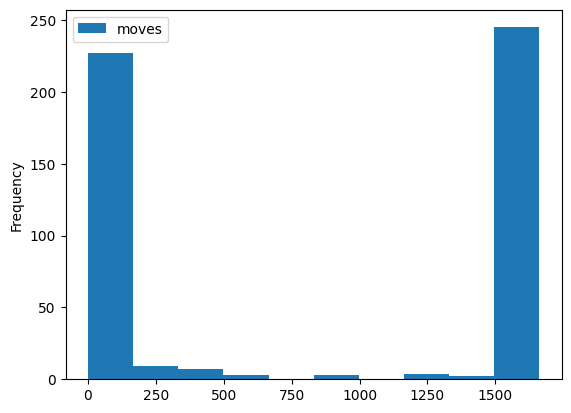

In [307]:
program_df.sort_values(by="moves", ascending=False, inplace=True)
program_df.plot(x="index", y="moves", kind="hist")
plt.show()

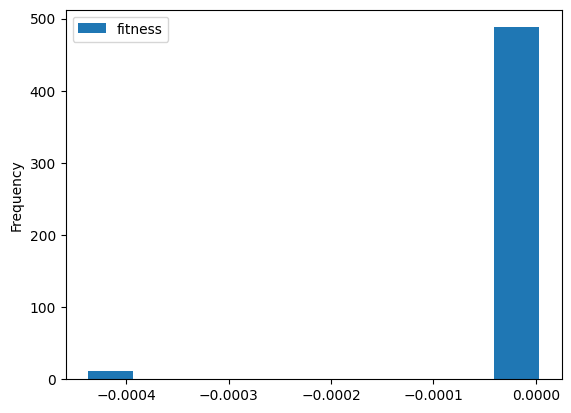

In [ ]:
program_df.sort_values(by="fitness", ascending=False, inplace=True)
program_df.plot(x="index", y="fitness", kind="hist")
plt.show()

In [306]:
print((program_df['fitness'] > 0).sum())
print(program_df[program_df['fitness'] > 0]['expression'].values)
print(program_df[program_df['fitness'] > 0]['moves'].values)
print(program_df[program_df['fitness'] > 0]['fitness'].values)

3
['(((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))) - ADX) * ADX) - OBV) / OBV)'
 '(((ADX * CMF) - OBV) / OBV)'
 '(((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))) - ADX) * ADX) - ATR) / OBV)']
[868. 868. 868.]
[3.20345297e-06 3.20345297e-06 3.20345297e-06]


In [303]:
print(program_df['expression'])

0      (((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))...
417                          (((ADX * CMF) - OBV) / OBV)
233    (((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))...
282    ((((OBV / (((((OBV + ATR) * (bollinger_band_wi...
224    (((donchian_channel_position - OBV) - (OBV * R...
                             ...                        
81     ((((stochastic_oscillator * 5) - ADX) / (OBV -...
264    (((OBV / OBV) / ((CMF / SMA) - (stochastic_osc...
334    (((((ATR * ((((7 / donchian_channel_position) ...
240    (((((ATR / OBV) * (((OBV / OBV) / ((RSI + (OBV...
355                                            (2 / OBV)
Name: expression, Length: 500, dtype: object


In [309]:
print(program_df.head(10))

    Program Fitness Expression  index  \
417     NaN     NaN        NaN  417.0   
233     NaN     NaN        NaN  233.0   
0       NaN     NaN        NaN    0.0   
497     NaN     NaN        NaN  497.0   
440     NaN     NaN        NaN  440.0   
224     NaN     NaN        NaN  224.0   
282     NaN     NaN        NaN  282.0   
2       NaN     NaN        NaN    2.0   
251     NaN     NaN        NaN  251.0   
373     NaN     NaN        NaN  373.0   

                                               program   fitness  \
417                        (((ADX * CMF) - OBV) / OBV)  0.000003   
233  (((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))...  0.000003   
0    (((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))...  0.000003   
497  ((((OBV / (((((OBV + ATR) * (bollinger_band_wi... -0.000003   
440  ((((OBV / (((((OBV + ATR) * (bollinger_band_wi... -0.000003   
224  (((donchian_channel_position - OBV) - (OBV * R... -0.000003   
282  ((((OBV / (((((OBV + ATR) * (bollinger_band_wi... -0.000003   
2   

Population size: 500
Fitness > 0: 3
Fitness <= 0: 497

Fitness stats:
count    500.000000
mean      -0.000017
std        0.000064
min       -0.000437
25%       -0.000009
50%       -0.000005
75%       -0.000005
max        0.000003
Name: fitness, dtype: float64


,index,fitness,moves,expression
417,417.0,0.000003,868.0,(((ADX * CMF) - OBV) / OBV)
233,233.0,0.000003,868.0,(((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))...
0,0.0,0.000003,868.0,(((((ATR - (ADX / ((OBV - (RSI / OBV)) - OBV))...
497,497.0,-0.000003,2.0,((((OBV / (((((OBV + ATR) * (bollinger_band_wi...
440,440.0,-0.000003,2.0,((((OBV / (((((OBV + ATR) * (bollinger_band_wi...
224,224.0,-0.000003,2.0,(((donchian_channel_position - OBV) - (OBV * R...
282,282.0,-0.000003,2.0,((((OBV / (((((OBV + ATR) * (bollinger_band_wi...
2,2.0,-0.000003,1655.0,(((((ATR - (OBV / ((OBV - (OBV - ADX)) - ((OBV...
251,251.0,-0.000003,1655.0,((((ATR - OBV) * ADX) - OBV) / OBV)
373,373.0,-0.000003,1655.0,ATR


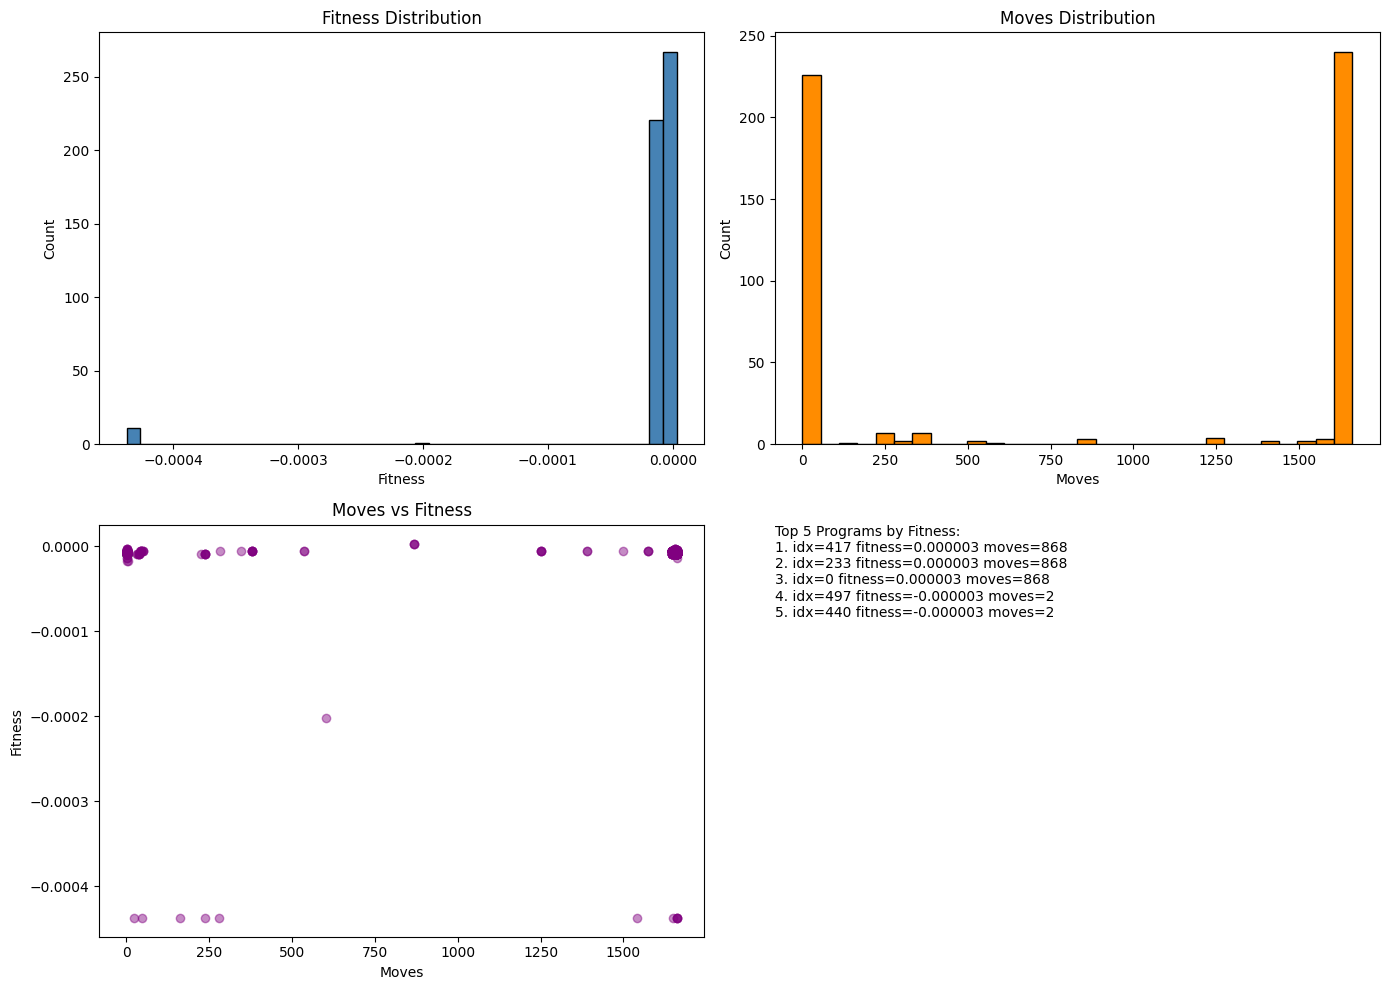

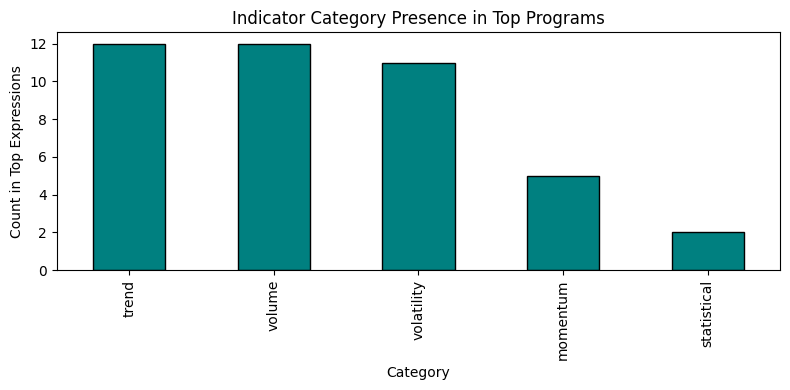

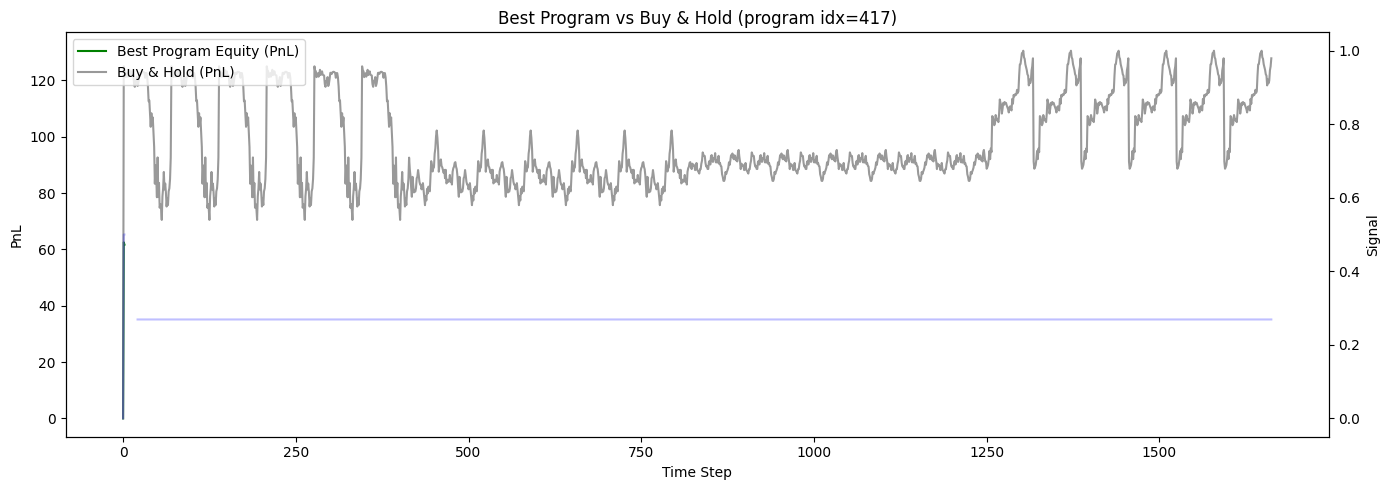

In [310]:
# GP process analysis dashboard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'program_df' not in globals():
    raise ValueError("program_df not found. Run the evolution cells first.")

analysis_df = program_df.copy()
analysis_df["fitness"] = pd.to_numeric(analysis_df["fitness"], errors="coerce")
analysis_df["moves"] = pd.to_numeric(analysis_df["moves"], errors="coerce")
analysis_df = analysis_df.dropna(subset=["fitness"])

# Basic summary
print("Population size:", len(analysis_df))
print("Fitness > 0:", int((analysis_df["fitness"] > 0).sum()))
print("Fitness <= 0:", int((analysis_df["fitness"] <= 0).sum()))
print("\nFitness stats:")
print(analysis_df["fitness"].describe())

# Top programs table
top_n = 10
top_df = analysis_df.sort_values("fitness", ascending=False).head(top_n)
display(top_df[["index", "fitness", "moves", "expression"]])

# Figure 1: fitness/moves distributions + relationship
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].hist(analysis_df["fitness"], bins=40, color="steelblue", edgecolor="black")
axs[0, 0].set_title("Fitness Distribution")
axs[0, 0].set_xlabel("Fitness")
axs[0, 0].set_ylabel("Count")

axs[0, 1].hist(analysis_df["moves"].dropna(), bins=30, color="darkorange", edgecolor="black")
axs[0, 1].set_title("Moves Distribution")
axs[0, 1].set_xlabel("Moves")
axs[0, 1].set_ylabel("Count")

axs[1, 0].scatter(analysis_df["moves"], analysis_df["fitness"], alpha=0.45, color="purple")
axs[1, 0].set_title("Moves vs Fitness")
axs[1, 0].set_xlabel("Moves")
axs[1, 0].set_ylabel("Fitness")

axs[1, 1].axis("off")
axs[1, 1].text(
    0.0,
    1.0,
    "Top 5 Programs by Fitness:\n" + "\n".join([
        f"{i+1}. idx={int(r['index'])} fitness={r['fitness']:.6f} moves={int(r['moves']) if pd.notna(r['moves']) else 'NA'}"
        for i, (_, r) in enumerate(top_df.head(5).iterrows())
    ]),
    va="top",
    fontsize=10,
)

plt.tight_layout()
plt.show()

# Figure 2: category usage among top programs (string match on expression)
if "functions" in globals():
    indicator_meta = {v["name"]: v.get("categories", []) for v in functions.values()}
    category_counts = {}

    for _, row in top_df.iterrows():
        expr = str(row["expression"])
        for ind_name, cats in indicator_meta.items():
            if ind_name in expr:
                for c in cats:
                    category_counts[c] = category_counts.get(c, 0) + 1

    if len(category_counts) > 0:
        cat_s = pd.Series(category_counts).sort_values(ascending=False)
        plt.figure(figsize=(8, 4))
        cat_s.plot(kind="bar", color="teal", edgecolor="black")
        plt.title("Indicator Category Presence in Top Programs")
        plt.xlabel("Category")
        plt.ylabel("Count in Top Expressions")
        plt.tight_layout()
        plt.show()

# Figure 3: best program equity curve vs buy/hold
required = {"programs", "df", "sigmoid_framework"}
if required.issubset(set(globals().keys())) and len(top_df) > 0:
    best_idx = int(top_df.iloc[0]["index"])
    best_program = programs[best_idx]

    prices = pd.to_numeric(df["price"], errors="coerce").ffill().bfill().values
    strat_curve = np.zeros(len(prices), dtype=float)
    buy_hold_curve = prices - prices[0]
    signals = np.zeros(len(prices), dtype=float)

    for i in range(1, len(prices)):
        prev_row = df.iloc[i - 1]
        s = float(sigmoid_framework(best_program, prev_row))
        signals[i] = s
        step_pnl = (prices[i] - prices[i - 1]) * s
        strat_curve[i] = strat_curve[i - 1] + step_pnl

    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(strat_curve, label="Best Program Equity (PnL)", color="green")
    ax1.plot(buy_hold_curve, label="Buy & Hold (PnL)", color="gray", alpha=0.8)
    ax1.set_title(f"Best Program vs Buy & Hold (program idx={best_idx})")
    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("PnL")
    ax1.legend(loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(signals, label="Signal (sigmoid)", color="blue", alpha=0.25)
    ax2.set_ylabel("Signal")
    ax2.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

In [304]:
# just some leftover stuff where I was trying to do it non-recursively

#for i in range(INITIAL_POPULATION * 2): # im doing like 2x because my idea is that each node has 2 children
#    indicators = []                     # but mabey I should make it random and make it random if some of the subtrees only have 1 child
#    for _ in range(INITIAL_DEPTH):      # I guess i dont know if i should do grow or full method, or the ramped half-andh-half
#        key = random.choice(list(functions.keys())) # did not know you could do this
#        indicators.append(functions[key]["name"])
#    
#    operators = []
#    for _ in range(INITIAL_DEPTH):
#        operators.append(random.choice(ops))
#
#
#    # now I dont really know how to build a tree
#    programs.append(node())
